# testing

> Create images for use in testing the pipeline.

In [ ]:
# | default_exp euclid.testing

### Approach

We want the following sets of test images. To ensure they are otherwise identical to the true data, we will create these by copying real data files and replacing the data.

**1. Constant background**
- *for basic test of ICL profile and colour measurements to establish that the code is working correctly*
- based on stacked cutout of an individual cluster
- simple Poisson-sampled Sérsic BCG+ICL model
- flat background with constant Gaussian noise matching real image

**2. Varying background**
- *for evaluating our ability to correctly estimate uncertainties due to the background and use these when determining profile extent, shape, colour, etc.*
- a) Sky patch
    - based on stacked cutout of sky patch
    - spatially varying background with constant Gaussian noise, tuned to match real image
- b) Cluster
    - based on stacked cutout of an individual cluster
    - independent realisation of background with same statistics as sky patch

**3. Real background**
- *for full test of ICL profile and colour measurements to check the effect of the real background and source masking*
- based on stacked cutout of an individual cluster
- simple Poisson-sampled Sérsic BCG+ICL model
- added to real stacked image: authentic background and sources

**4. Individual dithers** (postponed)
- *for end-to-end test of the processing pipeline to determine quality of the post-processing in preserving ICL*
- based on individual calibrated frames for a set of observations, e.g. the sky patch
- simple Sérsic BCG+ICL models
- added to real dither images, after autodark and continuity corrections: authentic background and sources

In [ ]:
# | export

from functools import partial

import astropy.units as u
import galsim
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.io import fits

from nicl import ezgal
from nicl.euclid.combine import combine
from nicl.euclid.data_access import default_data_path
from nicl.testing import create_test_background
from nicl.utilities import physical_to_angular

In [ ]:
# | hide
# Additional imports
from nicl.euclid.background_stats import measure

In [ ]:
# | export

TEST_IMAGES_OUTPATH = "test_images"
CLUSTER_REDSHIFT = 0.1
PIXEL_SCALE = 0.3 * u.arcsec / u.pix
BACKGROUND_RMS_LEVEL = 0.1  # relative to the pixel rms
BACKGROUND_SCALE = 500  # pixels
SKY_PATCH_SIZE = 1.5 * u.deg
SKY_PATCH_RA = 58.7 * u.deg
SKY_PATCH_DEC = -50.1 * u.deg

SKY_PATCH_SIZE_PIXELS = (SKY_PATCH_SIZE / PIXEL_SCALE).to_value(u.pix).astype(int)
SKY_PATCH_SHAPE = (SKY_PATCH_SIZE_PIXELS, SKY_PATCH_SIZE_PIXELS)

# This images needs to already exist. It is used as a template (header and shape) for the test images.
TEMPLATE_IMAGE_PATH = default_data_path("Q1_R1_clusters_v0.7", "tutku")
TEMPLATE_IMAGE_PATH /= "EUC_NIR_W-STK_Y-1eRASS J035423.6-475145.fits"

In [ ]:
# | export


def get_bcg_icl_mags(
    z=0.1,
    bcg_I_absmag=-25.0,
    icl_I_absmag=-25.5,
    bcg_zf=3.0,
    icl_zf=1.0,
):
    model = ezgal.model("bc03_ssp_z_0.02_chab.model")
    model.set_cosmology(Om=0.3, Ol=0.7, h=0.70, w=-1)
    distmod = model.get_distance_moduli(z, 1)
    bands = {band: f"Euclid-{band}.ecsv" for band in ["Y", "J", "H", "VIS"]}

    def calc_mags(zf, I_absmag):
        mags = {
            band: model.get_observed_absolute_mags(zf=zf, filters=filt, zs=z)
            for band, filt in bands.items()
        }
        model_I_absmag = model.get_absolute_mags(zf=zf, filters="bessell-I.ecsv", zs=z)
        delta_mag = I_absmag - model_I_absmag
        mags = {band: round(mags[band] + delta_mag + distmod, 2) for band in mags}
        return mags

    mags_bcg = calc_mags(bcg_zf, bcg_I_absmag)
    mags_icl = calc_mags(icl_zf, icl_I_absmag)
    return mags_bcg, mags_icl


def _mag_to_flux(mag, zp):
    return 10 ** (-(mag - zp) / 2.5)

In [ ]:
# | export


def create_test_images(
    outpath,
    cluster_redshift=None,
    shape=None,
    background_rms_level=None,
    background_scale=None,
    background_filenames=None,
    background_seed=0,
    bcg_n=4.6,
    bcg_re=22.6,
    bcg_q=0.6,
    bcg_theta=30,
    icl_n=0.76,
    icl_re=189.5,
    icl_q=0.6,
    icl_theta=60,
    icl_offset=(0, 0),  # offset in pixels (dx, dy)
    bcg_I_absmag=-24.5,
    icl_I_absmag=-24.5,
    bcg_zf=3.0,
    icl_zf=1.0,
    template_image_path=TEMPLATE_IMAGE_PATH,
):
    hdul = fits.open(template_image_path)
    if shape is None:
        shape = hdul["SCI"].shape
    else:
        hdul["SCI"].data = np.zeros_like(hdul["SCI"].data, shape=shape)
        hdul["RMS"].data = np.zeros_like(hdul["RMS"].data, shape=shape)
    zp = 23.9  # zeropoint for mJy
    rms = dict(H=0.023, J=0.023, Y=0.023, VIS=0.023)
    source_noise_level = 0.05  # relative noise added to sources
    pixscale = 0.3 * u.arcsec / u.pix

    if cluster_redshift:
        bcg_appmags, icl_appmags = get_bcg_icl_mags(
            cluster_redshift, bcg_I_absmag, icl_I_absmag, bcg_zf, icl_zf
        )
        bcg_re = (
            physical_to_angular(bcg_re * u.kpc, cluster_redshift) / pixscale
        ).to_value(u.pix)
        bcg = galsim.Sersic(n=bcg_n, half_light_radius=bcg_re, flux=1)
        bcg_shape = galsim.Shear(q=bcg_q, beta=bcg_theta * galsim.degrees)
        bcg = bcg.shear(bcg_shape)
        icl_re = (
            physical_to_angular(icl_re * u.kpc, cluster_redshift) / pixscale
        ).to_value(u.pix)
        icl = galsim.Sersic(n=icl_n, half_light_radius=icl_re, flux=1)
        icl_shape = galsim.Shear(q=icl_q, beta=icl_theta * galsim.degrees)
        icl = icl.shear(icl_shape)
        icl = icl.shift(
            tuple(x * pixscale.to_value(u.arcsec / u.pix) for x in icl_offset)
        )
        print(f"bcg_appmags: {bcg_appmags}")
        print(f"icl_appmags: {icl_appmags}")
        print(f"bcg_re: {bcg_re:.2f} pixels")
        print(f"icl_re: {icl_re:.2f} pixels")

    outpath.mkdir(parents=True, exist_ok=True)
    image = galsim.ImageF(*shape)
    label = "cluster" if cluster_redshift else "sky"

    for band in ["H", "J", "Y", "VIS"]:
        hdul["RMS"].data[:] = rms[band]
        if cluster_redshift:
            bcg_flux = _mag_to_flux(bcg_appmags[band], zp)
            icl_flux = _mag_to_flux(icl_appmags[band], zp)
            print(f"{band} bcg_flux: {bcg_flux:.2f}")
            print(f"{band} icl_flux: {icl_flux:.2f}")
            print(f"{band} bcg_flux + icl_flux: {bcg_flux + icl_flux:.2f}")
            cluster = bcg * bcg_flux + icl * icl_flux
            cluster.drawImage(image, method="no_pixel")
            hdul["SCI"].data[:] = image.array
            hdul.writeto(outpath / f"{label}_{band}_no_noise.fits", overwrite=True)
            source_noise = np.random.normal(
                scale=np.maximum(0, source_noise_level * image.array), size=shape
            )
            hdul["SCI"].data[:] += source_noise
        if background_filenames is not None:
            fn = default_data_path() / background_filenames[band]
            bkg_hdul = fits.open(fn)
            bkg = bkg_hdul["SCI"].data
            bkg_shape = bkg.shape
            rng = np.random.default_rng(background_seed)
            max_y = bkg_shape[0] - shape[0]
            max_x = bkg_shape[1] - shape[1]
            if max_y < 0 or max_x < 0:
                raise ValueError(
                    f"Background image size {bkg_shape} is too small for the required shape {shape}"
                )
            start_y = rng.integers(0, max_y + 1)
            start_x = rng.integers(0, max_x + 1)
            bkg = bkg[start_y : start_y + shape[0], start_x : start_x + shape[1]]
            hdul["SCI"].data[:] += bkg
        else:
            if background_rms_level is None:
                background_rms = None
            else:
                background_rms = background_rms_level * rms[band]
            _, _, background = create_test_background(
                shape,
                rms[band],
                background_scale=background_scale,
                background_rms=background_rms,
            )
            hdul["SCI"].data[:] += background
        hdul.writeto(outpath / f"{label}_{band}.fits", overwrite=True)

### 1. Constant background

The cluster is based on the fiducial values from Bellhouse et al. (2025), which are based on Kluge et al. (2021). By default, it is placed at lower redshift than Bellhouse et al. (2025). Magnitudes and colours are rough.

The background is flat, with an rms approximately corresponding to the real stacked images.

In [ ]:
# | export


def create_basic_cluster_test_images():
    outpath = default_data_path(TEST_IMAGES_OUTPATH) / "basic_test"
    create_test_images(outpath, cluster_redshift=CLUSTER_REDSHIFT)


def create_basic_sky_test_images():
    outpath = default_data_path(TEST_IMAGES_OUTPATH) / "basic_test"
    create_test_images(outpath, cluster_redshift=None, shape=SKY_PATCH_SHAPE)

In [ ]:
create_basic_sky_test_images()
create_basic_cluster_test_images()

### 2. Varying background

Identical to the previous test but now with a background that varies on a scale of 500 pixels. The rms of these large-scale variations is 10% of the individual pixel rms.

In [ ]:
# | export


def create_varying_background_cluster_test_images():
    outpath = default_data_path(TEST_IMAGES_OUTPATH) / "varying_background"
    create_test_images(
        outpath,
        cluster_redshift=CLUSTER_REDSHIFT,
        background_rms_level=BACKGROUND_RMS_LEVEL,
        background_scale=BACKGROUND_SCALE,
    )


def create_varying_background_sky_test_images():
    outpath = default_data_path(TEST_IMAGES_OUTPATH) / "varying_background"
    create_test_images(
        outpath,
        cluster_redshift=None,
        shape=SKY_PATCH_SHAPE,
        background_rms_level=BACKGROUND_RMS_LEVEL,
        background_scale=BACKGROUND_SCALE,
    )

In [ ]:
create_varying_background_sky_test_images()
create_varying_background_cluster_test_images()

bcg_appmags: {'Y': 12.86, 'J': 12.67, 'H': 12.48, 'VIS': 13.6}
icl_appmags: {'Y': 12.4, 'J': 12.24, 'H': 12.06, 'VIS': 13.08}
bcg_re: 40.85 pixels
icl_re: 342.50 pixels
H bcg_flux: 36982.82
H icl_flux: 54450.27
H bcg_flux + icl_flux: 91433.08
J bcg_flux: 31045.60
J icl_flux: 46131.76
J bcg_flux + icl_flux: 77177.35
Y bcg_flux: 26061.54
Y icl_flux: 39810.72
Y bcg_flux + icl_flux: 65872.25
VIS bcg_flux: 13182.57
VIS icl_flux: 21281.39
VIS bcg_flux + icl_flux: 34463.96


100%|██████████| 22/22 [00:33<00:00,  1.51s/it]


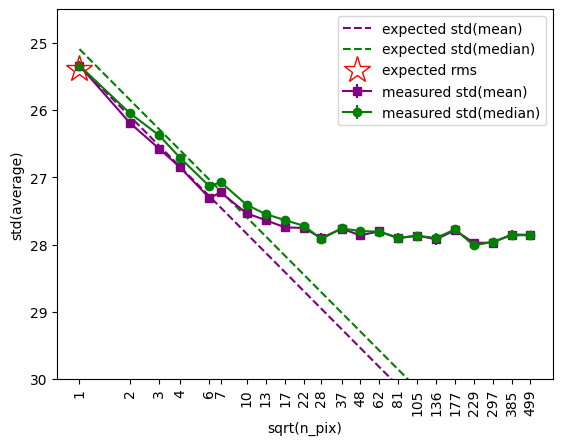

In [ ]:
stats = measure(
    "sky_H.fits",
    default_data_path(TEST_IMAGES_OUTPATH) / "varying_background",
    create_mask=False,
    n_apertures=500,
    max_sqrt_n_pix=500,
)

### 3. Real background

A real sky patch image is created and the same cluster model as above is inserted into a cutout of this image.

Creating the sky patch takes a long time and can be skipped if it already exists.

In [ ]:
# | export


def create_sky_patch(outpath, ra, dec, size):
    inpath = default_data_path("Q1_R1")

    # Until we have continuity/overlap background corrections implemented,
    # the current preferred approach is to perform a chip-by-chip background
    # subtraction for NIR, but no background subtraction for VIS.

    sky_combine = partial(
        combine,
        in_dir=inpath,
        out_dir=outpath,
        cutout_cen=SkyCoord(ra, dec),
        cutout_size=size,
        name="sky_patch",
        pixel_scale=0.3,
        overwrite=True,
    )

    sky_combine(
        filters=["Y", "J", "H"],
        bkg_sub=True,  # per-chip background is the default
    )

    sky_combine(
        filters=["I"],
        bkg_sub=False,
    )

In [ ]:
# Only run this if necessary
# create_sky_patch(default_data_path(TEST_IMAGES_OUTPATH) / "real_background", SKY_PATCH_RA, SKY_PATCH_DEC, SKY_PATCH_SIZE)

In [ ]:
# | export


def create_real_background_cluster_test_images(background_filenames):
    outpath = default_data_path(TEST_IMAGES_OUTPATH) / "real_background"
    create_test_images(
        outpath,
        cluster_redshift=CLUSTER_REDSHIFT,
        background_filenames=background_filenames,
    )

In [ ]:
background_filenames = {
    "H": f"{TEST_IMAGES_OUTPATH}/real_background/EUC_NIR_W-STK_H-sky_patch.fits",
    "J": f"{TEST_IMAGES_OUTPATH}/real_background/EUC_NIR_W-STK_J-sky_patch.fits",
    "Y": f"{TEST_IMAGES_OUTPATH}/real_background/EUC_NIR_W-STK_Y-sky_patch.fits",
    "VIS": f"{TEST_IMAGES_OUTPATH}/real_background/EUC_VIS_SWL-STK-sky_patch.fits",
}

In [ ]:
create_real_background_cluster_test_images(background_filenames)

bcg_appmags: {'Y': 12.86, 'J': 12.67, 'H': 12.48, 'VIS': 13.6}
icl_appmags: {'Y': 12.4, 'J': 12.24, 'H': 12.06, 'VIS': 13.08}
bcg_re: 40.85 pixels
icl_re: 342.50 pixels
H bcg_flux: 36982.82
H icl_flux: 54450.27
H bcg_flux + icl_flux: 91433.08
J bcg_flux: 31045.60
J icl_flux: 46131.76
J bcg_flux + icl_flux: 77177.35
Y bcg_flux: 26061.54
Y icl_flux: 39810.72
Y bcg_flux + icl_flux: 65872.25
VIS bcg_flux: 13182.57
VIS icl_flux: 21281.39
VIS bcg_flux + icl_flux: 34463.96


### 4. Individual dithers

As above, but with the cluster inserted into the individual dithers of the background region.

TBD
